# Between the Lines: Detection Gap Analysis
## Visualizations for the adversarial corpus (6,462 items). All four detection conditions: OpenAI and Perspective, pre and post-normalization.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv("../data/processed/detection_results_final.csv")

# Normalize flagged columns to bool
for col in ["openai_flagged", "openai_norm_flagged", "perspective_flagged", "perspective_norm_flagged"]:
    df[col] = df[col].map(lambda x: str(x).strip().lower() == "true")

# Subset scored by both APIs (pre-norm)
both_scored = df.dropna(subset=["openai_flagged", "perspective_flagged"])

print(f"Total items: {len(df)}")
print(f"Scored by both APIs: {len(both_scored)}")
print(f"\nOpenAI pre-norm flagged:      {df['openai_flagged'].sum():,} / {len(df):,} ({100*df['openai_flagged'].mean():.1f}%)")
print(f"OpenAI post-norm flagged:     {df['openai_norm_flagged'].sum():,} / {len(df):,} ({100*df['openai_norm_flagged'].mean():.1f}%)")
print(f"Perspective pre-norm flagged: {df['perspective_flagged'].sum():,} / {len(df):,} ({100*df['perspective_flagged'].mean():.1f}%)")
print(f"Perspective post-norm flagged:{df['perspective_norm_flagged'].sum():,} / {len(df):,} ({100*df['perspective_norm_flagged'].mean():.1f}%)")

Total items: 6462
Scored by both APIs: 6462

OpenAI pre-norm flagged:      2,421 / 6,462 (37.5%)
OpenAI post-norm flagged:     2,426 / 6,462 (37.5%)
Perspective pre-norm flagged: 343 / 6,462 (5.3%)
Perspective post-norm flagged:341 / 6,462 (5.3%)


## Figure 1: Detection Rate by Condition
## Normalization has essentially zero effect on flag rates for both APIs.

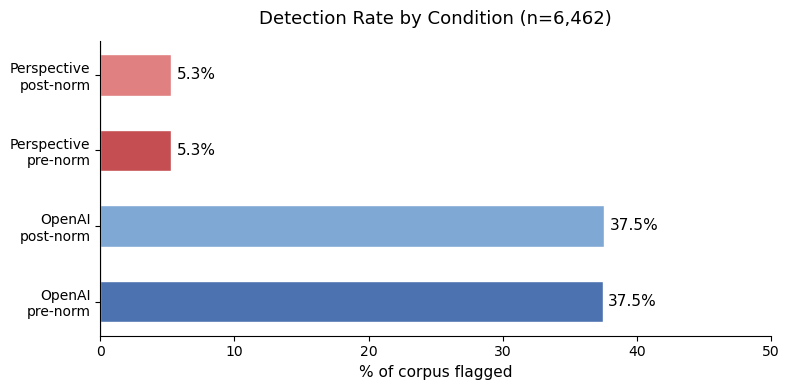

In [28]:
conditions = [
    ("OpenAI\npre-norm",       df["openai_flagged"].mean()),
    ("OpenAI\npost-norm",      df["openai_norm_flagged"].mean()),
    ("Perspective\npre-norm",  df["perspective_flagged"].mean()),
    ("Perspective\npost-norm", df["perspective_norm_flagged"].mean()),
]
labels, rates = zip(*conditions)
rates = [r * 100 for r in rates]

colors = ["#4C72B0", "#7FA8D4", "#C44E52", "#E08080"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(labels, rates, color=colors, edgecolor="white", height=0.55)

for bar, rate in zip(bars, rates):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
            f"{rate:.1f}%", va="center", fontsize=11)

ax.set_xlabel("% of corpus flagged", fontsize=11)
ax.set_xlim(0, 50)
ax.set_title("Detection Rate by Condition (n=6,462)", fontsize=13, pad=12)
ax.spines[["top", "right"]].set_visible(False)
ax.axvline(x=0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig("../data/figures/fig1_detection_rate_by_condition.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 2: API Agreement Breakdown
## Of the 6,348 items scored by both APIs, 61.4% were missed by both.

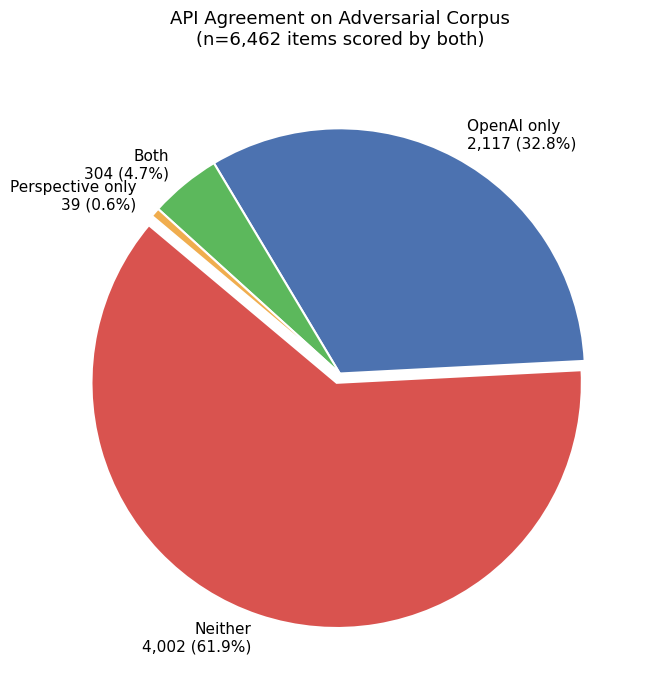

In [29]:
s = both_scored
n_both      = ((s["openai_flagged"]) & (s["perspective_flagged"])).sum()
n_openai    = ((s["openai_flagged"]) & (~s["perspective_flagged"])).sum()
n_persp     = ((~s["openai_flagged"]) & (s["perspective_flagged"])).sum()
n_neither   = ((~s["openai_flagged"]) & (~s["perspective_flagged"])).sum()
total       = len(s)

agreement_labels = [
    f"Neither\n{n_neither:,} ({100*n_neither/total:.1f}%)",
    f"OpenAI only\n{n_openai:,} ({100*n_openai/total:.1f}%)",
    f"Both\n{n_both:,} ({100*n_both/total:.1f}%)",
    f"Perspective only\n{n_persp:,} ({100*n_persp/total:.1f}%)",
]
sizes   = [n_neither, n_openai, n_both, n_persp]
colors  = ["#d9534f", "#4C72B0", "#5cb85c", "#f0ad4e"]
explode = [0.04, 0, 0, 0]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts = ax.pie(
    sizes, labels=agreement_labels, colors=colors, explode=explode,
    startangle=140, wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 11},
)
ax.set_title(f"API Agreement on Adversarial Corpus\n(n={total:,} items scored by both)", fontsize=13, pad=16)

plt.tight_layout()
plt.savefig("../data/figures/fig2_api_agreement.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 3: Detection Rate by Stratum
## OpenAI and Perspective flag rates across the three corpus strata.

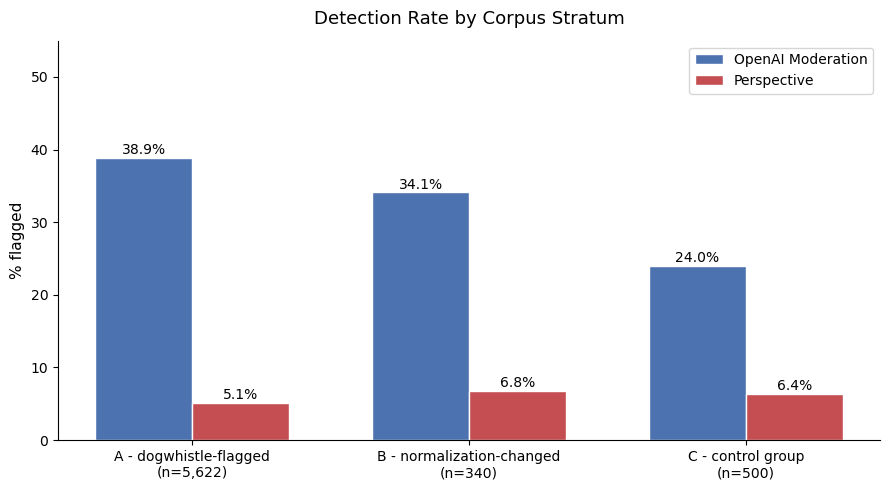

In [30]:
strata_order = ["A_dogwhistle", "B_normalized", "C_banned_control"]
strata_labels = ["A - dogwhistle-flagged\n(n=5,622)", "B - normalization-changed\n(n=340)", "C - control group\n(n=500)"]

openai_rates = [df[df["sample_stratum"]==s]["openai_flagged"].map(lambda x: str(x).strip().lower()=="true").mean()*100 for s in strata_order]

persp_rates  = [df[df["sample_stratum"]==s]["perspective_flagged"].map(lambda x: str(x).strip().lower()=="true").mean()*100 for s in strata_order]


x = np.arange(len(strata_order))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, openai_rates, width, label="OpenAI Moderation", color="#4C72B0", edgecolor="white")
b2 = ax.bar(x + width/2, persp_rates,  width, label="Perspective",        color="#C44E52", edgecolor="white")

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha="center", fontsize=10)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha="center", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(strata_labels, fontsize=10)
ax.set_ylabel("% flagged", fontsize=11)
ax.set_ylim(0, 55)
ax.set_title("Detection Rate by Corpus Stratum", fontsize=13, pad=12)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../data/figures/fig3_detection_by_stratum.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 4: Raw Score Distributions
## Distribution of OpenAI hate scores and Perspective toxicity scores. The dashed line marks each API's flag threshold.

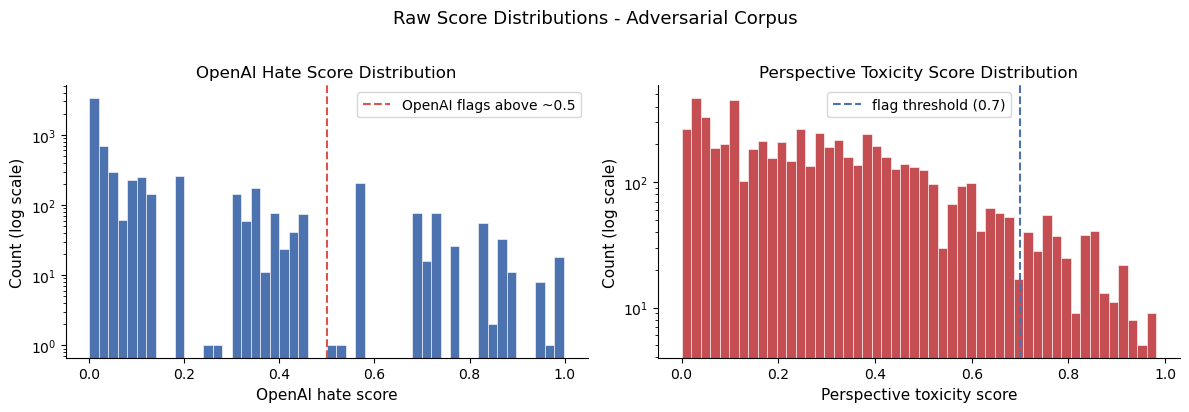

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# OpenAI hate score — log y-axis to show right-skewed distribution
openai_scores = pd.to_numeric(df["openai_hate"], errors="coerce").dropna()
axes[0].hist(openai_scores, bins=50, color="#4C72B0", edgecolor="white", linewidth=0.4)
axes[0].set_yscale("log")
axes[0].axvline(x=0.5, color="#d9534f", linestyle="--", linewidth=1.5, label="OpenAI flags above ~0.5")
axes[0].set_xlabel("OpenAI hate score", fontsize=11)
axes[0].set_ylabel("Count (log scale)", fontsize=11)
axes[0].set_title("OpenAI Hate Score Distribution", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].spines[["top", "right"]].set_visible(False)

# Perspective toxicity score — log y-axis
persp_scores = pd.to_numeric(df["perspective_toxicity"], errors="coerce").dropna()
axes[1].hist(persp_scores, bins=50, color="#C44E52", edgecolor="white", linewidth=0.4)
axes[1].set_yscale("log")
axes[1].axvline(x=0.7, color="#4C72B0", linestyle="--", linewidth=1.5, label="flag threshold (0.7)")
axes[1].set_xlabel("Perspective toxicity score", fontsize=11)
axes[1].set_ylabel("Count (log scale)", fontsize=11)
axes[1].set_title("Perspective Toxicity Score Distribution", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Raw Score Distributions - Adversarial Corpus", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/figures/fig4_score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()